In [1]:
# Cell 1: Install dependencies and import libraries

import os
import re
import json
import time
import glob
import warnings
import numpy as np
import pandas as pd
import PyPDF2
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from datetime import datetime
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_curve, auc)
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sentence_transformers import SentenceTransformer
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
print("✅ Semua library berhasil diimpor")

✅ Semua library berhasil diimpor


In [2]:
# Cell 2: Setup path lokal (tanpa Google Drive)

import os

# Deteksi otomatis root project (satu level di atas folder notebooks/)
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
BASE_PATH = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))

SOURCE_PDF_FOLDER = os.path.join(BASE_PATH, "data", "raw")

# Buat semua folder jika belum ada
os.makedirs(os.path.join(BASE_PATH, "data", "raw"),       exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, "data", "processed"), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, "data", "eval"),      exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, "data", "results"),   exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, "logs"),              exist_ok=True)

print(f"✅ BASE_PATH          : {BASE_PATH}")
print(f"✅ Folder PDF sumber  : {SOURCE_PDF_FOLDER}")
print(f"✅ Folder processed   : {os.path.join(BASE_PATH, 'data', 'processed')}")
print(f"✅ Folder eval        : {os.path.join(BASE_PATH, 'data', 'eval')}")
print(f"✅ Folder results     : {os.path.join(BASE_PATH, 'data', 'results')}")
print(f"✅ Folder logs        : {os.path.join(BASE_PATH, 'logs')}")

# Verifikasi PDF sudah ada
pdf_check = glob.glob(os.path.join(SOURCE_PDF_FOLDER, "**/*.pdf"), recursive=True)
pdf_check += glob.glob(os.path.join(SOURCE_PDF_FOLDER, "*.pdf"))
print(f"\n📁 PDF ditemukan di data/raw: {len(pdf_check)} file")
if len(pdf_check) == 0:
    print("⚠️  Belum ada PDF! Taruh semua file PDF putusan ke folder: data/raw/")
elif len(pdf_check) < 30:
    print(f"⚠️  Hanya {len(pdf_check)} PDF, minimal 30")
else:
    print(f"✅ Jumlah PDF memenuhi syarat (≥30)")

✅ BASE_PATH          : /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub
✅ Folder PDF sumber  : /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/raw
✅ Folder processed   : /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/processed
✅ Folder eval        : /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/eval
✅ Folder results     : /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/results
✅ Folder logs        : /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/logs

📁 PDF ditemukan di data/raw: 232 file
✅ Jumlah PDF memenuhi syarat (≥30)


In [3]:
# Cell 3: Text extraction and cleaning functions

def extract_text_from_pdf(pdf_path):
    """Ekstrak teks LENGKAP dari file PDF tanpa truncation."""
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            text = ""
            for page in reader.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
        return text
    except Exception as e:
        print(f"Gagal membaca {pdf_path}: {e}")
        return ""

def clean_text(raw_text):
    """Bersihkan teks dari header/footer, watermark, dan karakter tidak perlu."""
    # Hapus header putusan berulang
    text = re.sub(r'Putusan Nomor\s+\d+[\s\w/.]+\d{4}', '', raw_text)
    # Hapus nomor halaman
    text = re.sub(r'Halaman\s+\d+\s+dari\s+\d+', '', text)
    # Hapus disclaimer MA
    text = re.sub(r'Disclaimer[^.]*\.', '', text, flags=re.DOTALL | re.IGNORECASE)
    # Hapus mahkamah agung watermark
    text = re.sub(r'MAHKAMAH AGUNG', '', text, flags=re.IGNORECASE)
    # Normalisasi whitespace
    text = re.sub(r'\n{3,}', '\n\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()

def extract_relevant_section(text):
    """Ekstrak bagian fakta hukum dan pertimbangan — buang boilerplate."""
    if not isinstance(text, str) or len(text) < 100:
        return text

    start_markers = [
        "PERTIMBANGAN HUKUM",
        "TENTANG POKOK PERKARA",
        "TENTANG HUKUMNYA",
        "Menimbang",
    ]
    end_markers = [
        "MENGADILI",
        "AMAR PUTUSAN",
        "M E N G A D I L I",
    ]

    extracted = ""
    for start in start_markers:
        start_idx = text.find(start)
        if start_idx != -1:
            for end in end_markers:
                end_idx = text.find(end, start_idx)
                if end_idx != -1 and end_idx > start_idx + 100:
                    extracted = text[start_idx:end_idx]
                    break
            if extracted:
                break

    if not extracted:
        bahwa_idx = text.find("bahwa")
        extracted = text[bahwa_idx:bahwa_idx + 15000] if bahwa_idx != -1 else text[:15000]

    extracted = re.sub(r'\s+', ' ', extracted).strip()
    return extracted

print("✅ Fungsi teks berhasil didefinisikan")

✅ Fungsi teks berhasil didefinisikan


In [4]:
# Cell 4: Metadata extraction functions

def extract_metadata_enhanced(text, filename=""):
    """Ekstraksi metadata lengkap dari teks putusan."""
    metadata = {}

    # Nomor perkara
    patterns_perkara = [
        r'Nomor\s+(\d+\s+K/Pid\.Sus/\d{4})',
        r'Nomor\s+(\d+\s+Pid\.Sus/\d{4}/\w+)',
        r'NOMOR\s+(\d+/\w+/\d{4}/\w+)',
        r'(\d+\s*/\s*(?:K|PK)/Pid\.Sus/\d{4})',
        r'Nomor\s+(\d+\s+PK/Pid\.Sus/\d{4})',
        r'nomor\s+perkara\s*[:\s]+(\S+)',
    ]
    metadata['no_perkara'] = 'Tidak diketahui'
    for pattern in patterns_perkara:
        match = re.search(pattern, text, re.IGNORECASE)
        if match:
            metadata['no_perkara'] = match.group(1).strip()
            break

    # Tanggal putusan
    tanggal_match = re.search(
        r'(?:tanggal|dibacakan\s+pada|diputus\s+pada)\s+(\d{1,2}\s+\w+\s+\d{4})',
        text, re.IGNORECASE
    )
    metadata['tanggal'] = tanggal_match.group(1).strip() if tanggal_match else 'Tidak diketahui'

    # Jenis perkara
    if re.search(r'pencucian\s+uang', text, re.IGNORECASE):
        metadata['jenis_perkara'] = 'Pidana Khusus Pencucian Uang'
    elif re.search(r'narkotika', text, re.IGNORECASE):
        metadata['jenis_perkara'] = 'Pidana Khusus Narkotika'
    else:
        metadata['jenis_perkara'] = 'Pidana Khusus'

    # -------------------------------------------------------------------------
    # AMAR PUTUSAN — pola diperluas untuk menangkap semua format MA
    # -------------------------------------------------------------------------
    amar_text = 'Tidak ditemukan'

    # Pola 1: pidana penjara selama X (teks) tahun — format paling umum MA
    m = re.search(
        r'pidana\s+penjara\s+selama\s+(\d+)\s*(?:\([^)]+\))?\s*(?:\([^)]+\))?\s*tahun',
        text, re.IGNORECASE
    )
    if m:
        amar_text = f"Penjara {m.group(1)} tahun"

    # Pola 2: menjatuhkan pidana ... penjara selama X tahun
    if amar_text == 'Tidak ditemukan':
        m = re.search(
            r'menjatuhkan\s+pidana[^.]{0,80}penjara\s+selama\s+(\d+)\s*(?:\([^)]+\))?\s*tahun',
            text, re.IGNORECASE | re.DOTALL
        )
        if m:
            amar_text = f"Penjara {m.group(1)} tahun"

    # Pola 3: pidana penjara X tahun (tanpa "selama")
    if amar_text == 'Tidak ditemukan':
        m = re.search(
            r'pidana\s+penjara\s+(\d+)\s*(?:\([^)]+\))?\s*tahun',
            text, re.IGNORECASE
        )
        if m:
            amar_text = f"Penjara {m.group(1)} tahun"

    # Pola 4: penjara selama X tahun
    if amar_text == 'Tidak ditemukan':
        m = re.search(
            r'penjara\s+selama\s+(\d+)\s*(?:\([^)]+\))?\s*tahun',
            text, re.IGNORECASE
        )
        if m:
            amar_text = f"Penjara {m.group(1)} tahun"

    # Pola 5: hukuman penjara X tahun
    if amar_text == 'Tidak ditemukan':
        m = re.search(
            r'hukuman\s+penjara\s+(\d+)\s*(?:\([^)]+\))?\s*tahun',
            text, re.IGNORECASE
        )
        if m:
            amar_text = f"Penjara {m.group(1)} tahun"

    # Pola 6: vonis X tahun penjara (urutan terbalik)
    if amar_text == 'Tidak ditemukan':
        m = re.search(
            r'(\d+)\s*(?:\([^)]+\))?\s*tahun\s+penjara',
            text, re.IGNORECASE
        )
        if m:
            amar_text = f"Penjara {m.group(1)} tahun"

    # Pola 7: "selama X (teks) tahun" di sekitar konteks amar
    if amar_text == 'Tidak ditemukan':
        amar_section = re.search(
            r'(?:MENGADILI|AMAR|M\s*E\s*N\s*G\s*A\s*D\s*I\s*L\s*I).{0,500}',
            text, re.IGNORECASE | re.DOTALL
        )
        if amar_section:
            section = amar_section.group(0)
            m = re.search(r'(\d+)\s*(?:\([^)]+\))?\s*tahun', section, re.IGNORECASE)
            if m:
                amar_text = f"Penjara {m.group(1)} tahun"

    # Deteksi bebas / lepas
    if amar_text == 'Tidak ditemukan':
        if re.search(r'\bbebas\b|vrijspraak|lepas\s+dari\s+segala', text, re.IGNORECASE):
            amar_text = 'Bebas'

    # Deteksi pidana mati
    if amar_text == 'Tidak ditemukan':
        if re.search(r'pidana\s+mati|hukuman\s+mati', text, re.IGNORECASE):
            amar_text = 'Pidana Mati'

    # Deteksi pidana seumur hidup
    if amar_text == 'Tidak ditemukan':
        if re.search(r'penjara\s+seumur\s+hidup|pidana\s+seumur\s+hidup', text, re.IGNORECASE):
            amar_text = 'Penjara Seumur Hidup'

    metadata['amar_putusan'] = amar_text

    # Pasal yang digunakan
    pasal_matches = re.findall(
        r'Pasal\s+(\d+[A-Za-z]?(?:\s+ayat\s*\(\d+\))?)\s*(?:jo\.?\s*Pasal\s+\d+[A-Za-z]?)?\s*'
        r'(?:KUHP|Undang-Undang|UU|KUHAP)',
        text, re.IGNORECASE
    )
    # Juga tangkap pola "Pasal X UU No. Y"
    pasal_matches2 = re.findall(r'Pasal\s+(\d+[A-Za-z]?)\s+(?:UU|Undang-Undang)\s+(?:No|Nomor)', text, re.IGNORECASE)
    all_pasal = list(dict.fromkeys(pasal_matches + pasal_matches2))
    metadata['pasal'] = ', '.join(all_pasal)[:300] if all_pasal else 'Tidak diketahui'

    # Pihak — coba berbagai pola nama terdakwa
    pihak = 'Tidak diketahui'
    pihak_patterns = [
        r'(?:Terdakwa|terdakwa)\s*[:\-]?\s*([A-Z][A-Za-z\s\.]+?)(?:\s*(?:bin|binti|alias|,|\n))',
        r'Pemohon\s+Kasasi\s*[:\-]?\s*([A-Z][A-Za-z\s\.]+?)(?:\s*(?:,|\n|;))',
        r'nama\s*[:\-]\s*([A-Z][A-Za-z\s\.]+?)(?:\s*(?:,|\n|;))',
        r'bernama\s+([A-Z][A-Za-z\s\.]+?)(?:\s*(?:,|\n|;))',
    ]
    for pattern in pihak_patterns:
        m = re.search(pattern, text)
        if m:
            pihak = m.group(1).strip()[:100]
            break
    metadata['pihak'] = pihak

    # Ringkasan fakta
    fakta_match = re.search(r'bahwa\s+(.{100,600}?)\.', text, re.IGNORECASE | re.DOTALL)
    metadata['ringkasan_fakta'] = fakta_match.group(1).strip()[:500] if fakta_match else text[:500]

    return metadata


def normalize_amar(amar_text):
    if pd.isna(amar_text): return 'Tidak diketahui'
    s = str(amar_text).lower()
    
    if 'bebas' in s: return 'Bebas'
    if 'mati' in s: return 'Pidana Mati'
    if 'seumur hidup' in s: return 'Seumur Hidup'
    
    m = re.search(r'(\d+)', s)
    if m:
        years = int(m.group(1))
        if years <= 4:   return 'Ringan (1-4 tahun)'
        elif years <= 8: return 'Sedang (5-8 tahun)'
        else:            return 'Berat (9+ tahun)'
    
    return 'Tidak diketahui'


print("✅ Fungsi metadata berhasil didefinisikan")

✅ Fungsi metadata berhasil didefinisikan


In [5]:
# Cell 5: Scan dan proses semua file PDF

def scan_pdf_files(folder_path):
    all_pdfs = glob.glob(os.path.join(folder_path, "**/*.pdf"), recursive=True)
    if not all_pdfs:
        all_pdfs = glob.glob(os.path.join(folder_path, "*.pdf"))
    return [f for f in all_pdfs if f.lower().endswith('.pdf')]


def process_single_pdf(pdf_path, base_output_path):
    """Proses satu file PDF: ekstrak, bersihkan, ekstrak metadata."""
    filename = os.path.basename(pdf_path)
    case_id = re.sub(r'[^\w\-]', '_', filename.replace('.pdf', '').lower())
    log_entry = {
        'filename': filename,
        'case_id': case_id,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'status': '',
        'text_length_raw': 0,
        'text_length_cleaned': 0,
        'amar_found': False,
        'pasal_found': False,
        'notes': '',
    }

    try:
        raw_text = extract_text_from_pdf(pdf_path)
        log_entry['text_length_raw'] = len(raw_text)

        if len(raw_text.strip()) < 500:
            raise ValueError(f"Teks terlalu pendek ({len(raw_text)} karakter)")

        cleaned_text = clean_text(raw_text)
        relevant_text = extract_relevant_section(cleaned_text)
        log_entry['text_length_cleaned'] = len(cleaned_text)

        # Validasi 80% konten tersedia
        coverage = len(cleaned_text) / max(len(raw_text), 1)
        if coverage < 0.5:
            log_entry['notes'] += f"Coverage rendah: {coverage:.1%}. "

        # Simpan teks bersih
        txt_path = f"{base_output_path}/data/raw/{case_id}.txt"
        with open(txt_path, 'w', encoding='utf-8') as f:
            f.write(cleaned_text)

        metadata = extract_metadata_enhanced(cleaned_text, filename)
        metadata['case_id'] = case_id
        metadata['filename'] = filename
        metadata['text_length'] = len(cleaned_text)
        metadata['text_full'] = relevant_text
        metadata['text_for_embed'] = relevant_text[:4000]

        # Catat kualitas ekstraksi metadata di log
        log_entry['amar_found'] = metadata['amar_putusan'] not in ['Tidak ditemukan', 'Tidak diketahui']
        log_entry['pasal_found'] = metadata['pasal'] != 'Tidak diketahui'
        log_entry['status'] = 'SUCCESS'
        if not log_entry['amar_found']:
            log_entry['notes'] += "Amar tidak ditemukan. "
        if not log_entry['pasal_found']:
            log_entry['notes'] += "Pasal tidak ditemukan. "

        return metadata, log_entry

    except Exception as e:
        log_entry['status'] = 'FAILED'
        log_entry['notes'] = str(e)
        return None, log_entry


# Scan
pdf_files = scan_pdf_files(SOURCE_PDF_FOLDER)
print(f"📁 Ditemukan {len(pdf_files)} file PDF")
if len(pdf_files) < 30:
    print(f"⚠️ PERINGATAN: Hanya {len(pdf_files)} file (minimal 30)")
else:
    print(f"✅ Jumlah file memenuhi syarat (≥ 30)")

# Proses semua PDF
all_cases = []
cleaning_logs = []
failed_files = []
start_time = time.time()

for pdf_path in tqdm(pdf_files, desc="Memproses PDF"):
    result, log_entry = process_single_pdf(pdf_path, BASE_PATH)
    cleaning_logs.append(log_entry)
    if result:
        all_cases.append(result)
    else:
        failed_files.append(log_entry['filename'])

elapsed = time.time() - start_time

# Simpan cleaning.log
log_df = pd.DataFrame(cleaning_logs)
log_csv_path = f"{BASE_PATH}/logs/cleaning.log"
log_df.to_csv(log_csv_path, index=False, encoding='utf-8')

print(f"\n✅ Berhasil : {len(all_cases)} | ❌ Gagal: {len(failed_files)} | ⏱️ {elapsed:.1f}s")
print(f"\n📊 Kualitas Ekstraksi Metadata:")
print(f"   Amar berhasil diekstrak : {log_df['amar_found'].sum()}/{len(log_df)} ({log_df['amar_found'].mean():.1%})")
print(f"   Pasal berhasil diekstrak: {log_df['pasal_found'].sum()}/{len(log_df)} ({log_df['pasal_found'].mean():.1%})")
print(f"✅ Cleaning log disimpan  : {log_csv_path}")

if failed_files:
    failed_log = f"{BASE_PATH}/logs/failed_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
    with open(failed_log, 'w') as f:
        f.write("\n".join(failed_files))
    print(f"📝 Failed files log      : {failed_log}")

📁 Ditemukan 116 file PDF
✅ Jumlah file memenuhi syarat (≥ 30)


Memproses PDF: 100%|██████████| 116/116 [01:54<00:00,  1.01it/s]


✅ Berhasil : 116 | ❌ Gagal: 0 | ⏱️ 114.9s

📊 Kualitas Ekstraksi Metadata:
   Amar berhasil diekstrak : 106/116 (91.4%)
   Pasal berhasil diekstrak: 101/116 (87.1%)
✅ Cleaning log disimpan  : /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/logs/cleaning.log


In [6]:
# Cell 6: Buat DataFrame, normalisasi amar, simpan ke CSV & JSON

df_cases = pd.DataFrame(all_cases).reset_index(drop=True)
df_cases['amar_normalized'] = df_cases['amar_putusan'].apply(normalize_amar)

# Validasi kelengkapan teks (minimal 80% isi tersedia)
df_cases['valid_text'] = df_cases['text_length'] > 1000
valid_count = df_cases['valid_text'].sum()
print(f"✅ Dokumen dengan teks valid (>1000 karakter): {valid_count}/{len(df_cases)}")

csv_path = f"{BASE_PATH}/data/processed/cases.csv"
json_path = f"{BASE_PATH}/data/processed/cases.json"

# Simpan semua kolom KECUALI teks panjang ke CSV (agar tidak terlalu besar)
cols_for_csv = [c for c in df_cases.columns if c not in ['text_full', 'text_for_embed']]
df_cases[cols_for_csv].to_csv(csv_path, index=False, encoding='utf-8')

# Simpan ke JSON (termasuk teks)
df_cases.to_json(json_path, orient='records', indent=2, force_ascii=False)

print(f"\n✅ CSV  : {csv_path}")
print(f"✅ JSON : {json_path}")
print(f"\n📋 Dataset Info:")
print(f"   - Jumlah kasus      : {len(df_cases)}")
print(f"   - Kolom             : {list(df_cases.columns)}")
print(f"   - Rata-rata panjang : {df_cases['text_length'].mean():.0f} karakter")
print(f"\n📊 Distribusi Amar Putusan:")
print(df_cases['amar_normalized'].value_counts().head(10))

✅ Dokumen dengan teks valid (>1000 karakter): 116/116

✅ CSV  : /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/processed/cases.csv
✅ JSON : /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/processed/cases.json

📋 Dataset Info:
   - Jumlah kasus      : 116
   - Kolom             : ['no_perkara', 'tanggal', 'jenis_perkara', 'amar_putusan', 'pasal', 'pihak', 'ringkasan_fakta', 'case_id', 'filename', 'text_length', 'text_full', 'text_for_embed', 'amar_normalized', 'valid_text']
   - Rata-rata panjang : 122188 karakter

📊 Distribusi Amar Putusan:
amar_normalized
Berat (9+ tahun)      45
Ringan (1-4 tahun)    31
Sedang (5-8 tahun)    23
Tidak diketahui       10
Bebas                  7
Name: count, dtype: int64


In [7]:
# Cell 7: Train/Test split (80:20) tanpa data leakage + simpan ground truth

from sklearn.model_selection import train_test_split

# Gunakan semua data untuk case base; split hanya untuk evaluasi supervised
# Filter hanya data dengan label jelas untuk evaluasi
labeled_data = df_cases[df_cases['amar_normalized'] != 'Tidak diketahui'].copy().reset_index(drop=True)
print(f"📊 Total data berlabel: {len(labeled_data)} dari {len(df_cases)}")

# Pastikan minimal 2 sample per kelas untuk stratified split
class_counts = labeled_data['amar_normalized'].value_counts()
valid_classes = class_counts[class_counts >= 2].index.tolist()
labeled_data = labeled_data[labeled_data['amar_normalized'].isin(valid_classes)].copy()
print(f"📊 Data setelah filter kelas ≥2 sampel: {len(labeled_data)}")

# Split 80:20 stratified
train_data, test_data = train_test_split(
    labeled_data,
    test_size=0.2,
    random_state=42,
    stratify=labeled_data['amar_normalized']
)
train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

print(f"\n✅ Data Train: {len(train_data)} kasus")
print(f"✅ Data Test : {len(test_data)} kasus")

# Simpan ground truth (hanya test set)
ground_truth = dict(zip(test_data['case_id'], test_data['amar_normalized']))
gt_path = f"{BASE_PATH}/data/eval/ground_truth.json"
with open(gt_path, 'w', encoding='utf-8') as f:
    json.dump(ground_truth, f, indent=2, ensure_ascii=False)

print(f"\n✅ Ground truth disimpan: {gt_path}")
print(f"   Total {len(ground_truth)} kasus test")

# Queries file untuk evaluasi retrieval (ambil 10 dari test)
queries = []
for _, row in test_data.head(10).iterrows():
    queries.append({
        "query_id": row['case_id'],
        "query_text": row['text_full'][:1000],
        "ground_truth_case_id": row['case_id'],
        "ground_truth_amar": row['amar_normalized']
    })

queries_path = f"{BASE_PATH}/data/eval/queries.json"
with open(queries_path, 'w', encoding='utf-8') as f:
    json.dump(queries, f, indent=2, ensure_ascii=False)

print(f"✅ File queries.json disimpan: {queries_path}")

📊 Total data berlabel: 106 dari 116
📊 Data setelah filter kelas ≥2 sampel: 106

✅ Data Train: 84 kasus
✅ Data Test : 22 kasus

✅ Ground truth disimpan: /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/eval/ground_truth.json
   Total 22 kasus test
✅ File queries.json disimpan: /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/eval/queries.json


In [8]:
# Cell 8: TF-IDF Retriever — dilatih HANYA pada train_data

INDONESIAN_STOP_WORDS = list(set([
    'yang', 'dan', 'di', 'dari', 'dengan', 'ini', 'itu', 'untuk', 'oleh',
    'pada', 'dalam', 'mereka', 'kami', 'kita', 'kamu', 'dia', 'ia', 'anda',
    'adalah', 'ada', 'bukan', 'tidak', 'juga', 'serta', 'bahwa', 'dapat',
    'akan', 'tersebut', 'bagi', 'sebagai', 'ke', 'kepada', 'sehingga',
    'saat', 'setelah', 'sebelum', 'kemudian', 'lagi', 'tanpa', 'karena',
    'jika', 'maka', 'sampai', 'pun', 'para', 'demi', 'atas', 'antara',
    'lalu', 'telah', 'sudah', 'sedang', 'lebih', 'sangat', 'hanya',
    'juga', 'namun', 'tetapi', 'atau', 'seperti', 'secara', 'atas',
    'terhadap', 'berdasarkan', 'merupakan', 'bahwa', 'hal', 'perkara',
    'putusan', 'pengadilan', 'mahkamah', 'agung', 'negeri', 'tinggi',
]))

def build_tfidf_retriever(df, text_column='text_full', max_features=3000):
    """
    Build TF-IDF vectorizer — difit pada df yang diberikan.
    max_features=3000 untuk menangkap lebih banyak fitur hukum.
    """
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        stop_words=INDONESIAN_STOP_WORDS,
        ngram_range=(1, 2),
        lowercase=True,
        strip_accents='unicode',
        min_df=2,
        max_df=0.90,
        sublinear_tf=True,   # Reduksi dominasi kata sangat sering
    )
    documents = df[text_column].fillna('').tolist()
    tfidf_matrix = vectorizer.fit_transform(documents)
    return vectorizer, tfidf_matrix


def retrieve_tfidf(query, df, vectorizer, tfidf_matrix, top_k=5):
    """
    Retrieve top-k kasus mirip dari df berdasarkan cosine similarity TF-IDF.
    """
    if not query or len(query.strip()) < 10:
        return pd.DataFrame()

    query_vec = vectorizer.transform([query])
    similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_indices = similarities.argsort()[-top_k:][::-1]
    valid_indices = [i for i in top_indices if similarities[i] > 0]

    if not valid_indices:
        return pd.DataFrame()

    results = df.iloc[valid_indices].copy().reset_index(drop=True)
    results['similarity'] = [similarities[i] for i in valid_indices]
    return results


def majority_vote(retrieved_df):
    """Pilih solusi (amar) yang paling banyak muncul di top-k."""
    if len(retrieved_df) == 0:
        return "Tidak diketahui"
    col = 'amar_normalized' if 'amar_normalized' in retrieved_df.columns else 'amar_putusan'
    modes = retrieved_df[col].mode()
    return modes[0] if len(modes) > 0 else "Tidak diketahui"


def weighted_vote(retrieved_df, similarity_threshold=0.05):
    """Pilih solusi berdasarkan bobot similarity tertinggi."""
    if len(retrieved_df) == 0:
        return "Tidak diketahui"

    col = 'amar_normalized' if 'amar_normalized' in retrieved_df.columns else 'amar_putusan'
    filtered = retrieved_df[retrieved_df['similarity'] >= similarity_threshold]
    if len(filtered) == 0:
        filtered = retrieved_df

    weights = filtered['similarity'].values
    weights = weights / weights.sum() if weights.sum() > 0 else weights
    solutions = filtered[col].values

    scores = {}
    for sol, w in zip(solutions, weights):
        scores[sol] = scores.get(sol, 0) + w

    return max(scores, key=scores.get)


def predict_outcome(query, train_df, vectorizer, tfidf_matrix, k=5):
    """
    Fungsi utama CBR: retrieve top-k → weighted vote → return prediksi.
    """
    top_k_results = retrieve_tfidf(query, train_df, vectorizer, tfidf_matrix, top_k=k)
    if len(top_k_results) == 0:
        return "Tidak diketahui", pd.DataFrame()
    prediction = weighted_vote(top_k_results)
    return prediction, top_k_results


# Build retriever dari train_data saja (tidak ada leakage ke test)
text_col = 'text_full'
print("🔧 Building TF-IDF retriever dari train_data...")
vectorizer, tfidf_matrix = build_tfidf_retriever(train_data, text_col, max_features=3000)

print(f"✅ TF-IDF dibangun dari {len(train_data)} dokumen train")
print(f"   Dimensi matriks: {tfidf_matrix.shape}")
print(f"   Jumlah fitur   : {len(vectorizer.get_feature_names_out())}")

🔧 Building TF-IDF retriever dari train_data...
✅ TF-IDF dibangun dari 84 dokumen train
   Dimensi matriks: (84, 3000)
   Jumlah fitur   : 3000


In [9]:
# Cell 8B: SVM dan Naive Bayes Classifier di atas TF-IDF
# (Sesuai spesifikasi tugas: "model ML seperti SVM atau Naive Bayes pada TF-IDF")

from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.model_selection import cross_val_score

print("~" * 70)
print("🤖 CLASSIFIER: SVM & NAIVE BAYES DI ATAS TF-IDF")
print("~" * 70)

# Gunakan labeled_data yang sudah di-split
X_train_text = train_data[text_col].fillna('').tolist()
X_test_text  = test_data[text_col].fillna('').tolist()
y_train      = train_data['amar_normalized'].tolist()
y_test       = test_data['amar_normalized'].tolist()

print(f"📊 Train: {len(X_train_text)} | Test: {len(X_test_text)}")
print(f"📊 Jumlah kelas: {len(set(y_train))}")

# TF-IDF vectorizer khusus untuk classifier
tfidf_clf = TfidfVectorizer(
    max_features=3000,
    stop_words=INDONESIAN_STOP_WORDS,
    ngram_range=(1, 2),
    lowercase=True,
    strip_accents='unicode',
    min_df=2,
    max_df=0.90,
    sublinear_tf=True,
)

X_train_tfidf = tfidf_clf.fit_transform(X_train_text)
X_test_tfidf  = tfidf_clf.transform(X_test_text)

print(f"✅ TF-IDF matrix train: {X_train_tfidf.shape}")

# ── 1. SVM Classifier ────────────────────────────────────────────────────────
print("\n🔷 Training SVM (RBF kernel) ...")
svm_clf = SVC(
    kernel='linear',     # Linear lebih baik untuk teks
    C=1.0,
    probability=True,
    random_state=42,
    class_weight='balanced'  # Atasi imbalanced class
)
svm_clf.fit(X_train_tfidf, y_train)

y_pred_svm = svm_clf.predict(X_test_tfidf)

svm_acc  = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_rec  = recall_score(y_test, y_pred_svm, average='weighted', zero_division=0)
svm_f1   = f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)

print(f"  Accuracy : {svm_acc:.4f}")
print(f"  Precision: {svm_prec:.4f}")
print(f"  Recall   : {svm_rec:.4f}")
print(f"  F1-Score : {svm_f1:.4f}")

# ── 2. Naive Bayes Classifier (ComplementNB lebih baik untuk imbalanced) ─────
print("\n🔶 Training Complement Naive Bayes ...")
nb_clf = ComplementNB(alpha=0.5)
nb_clf.fit(X_train_tfidf, y_train)

y_pred_nb = nb_clf.predict(X_test_tfidf)

nb_acc  = accuracy_score(y_test, y_pred_nb)
nb_prec = precision_score(y_test, y_pred_nb, average='weighted', zero_division=0)
nb_rec  = recall_score(y_test, y_pred_nb, average='weighted', zero_division=0)
nb_f1   = f1_score(y_test, y_pred_nb, average='weighted', zero_division=0)

print(f"  Accuracy : {nb_acc:.4f}")
print(f"  Precision: {nb_prec:.4f}")
print(f"  Recall   : {nb_rec:.4f}")
print(f"  F1-Score : {nb_f1:.4f}")

# ── 3. Cross-Validation SVM (5-fold) ─────────────────────────────────────────
print("\n📊 5-Fold Cross Validation SVM ...")
svm_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=3000, stop_words=INDONESIAN_STOP_WORDS,
        ngram_range=(1, 2), sublinear_tf=True, min_df=2, max_df=0.90
    )),
    ('clf', SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42))
])

cv_scores_svm = cross_val_score(
    svm_pipeline,
    labeled_data[text_col].fillna('').tolist(),
    labeled_data['amar_normalized'].tolist(),
    cv=5, scoring='accuracy'
)
print(f"  CV Scores : {[f'{s:.4f}' for s in cv_scores_svm]}")
print(f"  Mean ± Std: {cv_scores_svm.mean():.4f} ± {cv_scores_svm.std():.4f}")

# ── 4. Classification Report ──────────────────────────────────────────────────
print("\n📋 Classification Report — SVM:")
print(classification_report(y_test, y_pred_svm, zero_division=0))

print("📋 Classification Report — Naive Bayes:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

# ── 5. Fungsi retrieve menggunakan SVM (untuk CBR pipeline) ──────────────────
def retrieve_with_svm(query, train_df, tfidf_vectorizer, svm_model, top_k=5):
    """
    Retrieve + classify kasus baru menggunakan SVM.
    Return top-k berdasarkan cosine similarity + prediksi label dari SVM.
    """
    query_vec = tfidf_vectorizer.transform([query])

    # SVM prediction
    svm_label = svm_model.predict(query_vec)[0]
    svm_proba = svm_model.predict_proba(query_vec)[0]
    svm_confidence = max(svm_proba)

    # Cosine similarity untuk top-k retrieval
    tfidf_all = tfidf_vectorizer.transform(train_df[text_col].fillna('').tolist())
    sims = cosine_similarity(query_vec, tfidf_all).flatten()
    top_indices = sims.argsort()[-top_k:][::-1]

    results = train_df.iloc[top_indices].copy().reset_index(drop=True)
    results['similarity'] = sims[top_indices]

    return results, svm_label, svm_confidence


# ── 6. Simpan metrics classifier ─────────────────────────────────────────────
clf_metrics = pd.DataFrame([
    {'model': 'SVM (Linear)', 'accuracy': svm_acc, 'precision': svm_prec,
     'recall': svm_rec, 'f1': svm_f1, 'cv_mean': cv_scores_svm.mean(), 'cv_std': cv_scores_svm.std()},
    {'model': 'Complement NB', 'accuracy': nb_acc, 'precision': nb_prec,
     'recall': nb_rec, 'f1': nb_f1, 'cv_mean': 0, 'cv_std': 0},
])
clf_metrics.to_csv(f"{BASE_PATH}/data/eval/classifier_metrics.csv", index=False)
print(f"\n✅ Classifier metrics disimpan: {BASE_PATH}/data/eval/classifier_metrics.csv")

# Simpan model untuk dipakai di demo
import pickle
with open(f"{BASE_PATH}/data/processed/svm_model.pkl", 'wb') as f:
    pickle.dump({'tfidf': tfidf_clf, 'svm': svm_clf, 'nb': nb_clf}, f)
print(f"✅ Model SVM & NB disimpan")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🤖 CLASSIFIER: SVM & NAIVE BAYES DI ATAS TF-IDF
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
📊 Train: 84 | Test: 22
📊 Jumlah kelas: 4
✅ TF-IDF matrix train: (84, 3000)

🔷 Training SVM (RBF kernel) ...
  Accuracy : 0.4091
  Precision: 0.5727
  Recall   : 0.4091
  F1-Score : 0.3885

🔶 Training Complement Naive Bayes ...
  Accuracy : 0.4091
  Precision: 0.5321
  Recall   : 0.4091
  F1-Score : 0.3588

📊 5-Fold Cross Validation SVM ...
  CV Scores : ['0.5455', '0.7619', '0.5714', '0.5714', '0.3810']
  Mean ± Std: 0.5662 ± 0.1209

📋 Classification Report — SVM:
                    precision    recall  f1-score   support

             Bebas       1.00      0.50      0.67         2
  Berat (9+ tahun)       0.40      0.67      0.50         9
Ringan (1-4 tahun)       1.00      0.17      0.29         6
Sedang (5-8 tahun)       0.20      0.20      0.20         5

          accuracy                      

In [11]:
pip install -U huggingface_hub sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.1/721.1 kB 6.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 21.9 MB/s  0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.19.0
    Uninstalling huggingface_hub-1.19.0:
      Successfully uninstalled huggingface_hub-1.19.0
  Attempting uninstall: sentence-transformers━━━ 0/2 [huggingface_hub]
    Found existing installation: sentence-transformers 5.5.1m [huggingface_hub]
    Uninstalling sentence-transformers-5.5.1: 0/2 [huggingface_hub]
      Successfully uninstalled sentence-transformers-5.5.1 [huggingface_hub]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [sentence-transformers]ence-transformers]
Note: you may need to restart the kernel to use updated packages.


In [12]:
# Cell 9: BERT/SentenceTransformer Embedding Retriever

print("📥 Memuat model SentenceTransformer multilingual...")
bert_model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
print(f"✅ Model loaded: {bert_model.get_sentence_embedding_dimension()} dimensi")


def embed_texts(df, text_column='text_for_embed', batch_size=16):
    """Buat embedding untuk semua dokumen dalam df."""
    documents = df[text_column].fillna('').tolist()
    embeddings = bert_model.encode(
        documents,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True   # L2 normalize → cosine sim = dot product
    )
    return embeddings


def retrieve_bert(query, df, embeddings, top_k=5):
    """Retrieve top-k kasus menggunakan BERT embedding cosine similarity."""
    query_emb = bert_model.encode([query[:4000]], convert_to_numpy=True, normalize_embeddings=True)
    similarities = cosine_similarity(query_emb, embeddings).flatten()
    top_indices = similarities.argsort()[-top_k:][::-1]
    results = df.iloc[top_indices].copy().reset_index(drop=True)
    results['similarity'] = similarities[top_indices]
    return results


# Embed HANYA train_data
print(f"\n🚀 Menghitung BERT embedding untuk {len(train_data)} dokumen train...")
train_embeddings = embed_texts(train_data, 'text_for_embed', batch_size=16)

embed_path = f"{BASE_PATH}/data/processed/train_embeddings.npy"
np.save(embed_path, train_embeddings)
print(f"✅ Embedding disimpan: {embed_path}")
print(f"   Shape: {train_embeddings.shape}")

# Quick test retrieval
sample_query = test_data.iloc[0]['text_full'][:1000]
hasil_bert_test = retrieve_bert(sample_query, train_data, train_embeddings, top_k=3)
print("\n📋 Contoh BERT retrieval (Top 3):")
print(hasil_bert_test[['case_id', 'amar_normalized', 'similarity']].to_string(index=False))

📥 Memuat model SentenceTransformer multilingual...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ Model loaded: 384 dimensi

🚀 Menghitung BERT embedding untuk 84 dokumen train...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

✅ Embedding disimpan: /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/processed/train_embeddings.npy
   Shape: (84, 384)

📋 Contoh BERT retrieval (Top 3):
                                   case_id    amar_normalized  similarity
putusan_4295_k_pid_sus_2023_20260527092132 Sedang (5-8 tahun)    0.943733
putusan_4899_k_pid_sus_2023_20260605134050   Berat (9+ tahun)    0.930477
putusan_4945_k_pid_sus_2022_20260605180844              Bebas    0.919432


In [13]:
# Cell 10: Prediksi pada test_data menggunakan TF-IDF (tanpa data leakage)

print(f"🚀 Prediksi untuk {len(test_data)} kasus test...")
print("~" * 60)

predictions_tfidf = []

for idx, row in tqdm(test_data.iterrows(), total=len(test_data), desc="Prediksi TF-IDF"):
    query = row[text_col]

    # KUNCI: retrieve dari train_data + tfidf_matrix train, BUKAN dari df_cases penuh
    pred_amar, top_k_results = predict_outcome(query, train_data, vectorizer, tfidf_matrix, k=5)

    top5_ids = top_k_results['case_id'].tolist() if len(top_k_results) > 0 else []
    avg_sim = top_k_results['similarity'].mean() if len(top_k_results) > 0 else 0.0

    predictions_tfidf.append({
        'query_id': row['case_id'],
        'true_amar': row['amar_normalized'],
        'predicted_amar': pred_amar,
        'top_5_case_ids': str(top5_ids),
        'avg_similarity': avg_sim,
        'correct': row['amar_normalized'] == pred_amar,
    })

pred_df = pd.DataFrame(predictions_tfidf)

# Simpan predictions
pred_path = f"{BASE_PATH}/data/results/predictions.csv"
pred_df.to_csv(pred_path, index=False, encoding='utf-8')

accuracy = pred_df['correct'].mean()
print(f"\n📊 Akurasi TF-IDF (test set): {accuracy:.2%} ({pred_df['correct'].sum()}/{len(pred_df)})")
print(pred_df[['query_id', 'true_amar', 'predicted_amar', 'avg_similarity', 'correct']].to_string(index=False))

🚀 Prediksi untuk 22 kasus test...
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


Prediksi TF-IDF: 100%|██████████| 22/22 [00:00<00:00, 470.42it/s]


📊 Akurasi TF-IDF (test set): 45.45% (10/22)
                                     query_id          true_amar     predicted_amar  avg_similarity  correct
   putusan_2770_k_pid_sus_2024_20260531082304 Sedang (5-8 tahun)   Berat (9+ tahun)        0.441532    False
   putusan_227_pk_pid_sus_2018_20260517155844   Berat (9+ tahun)   Berat (9+ tahun)        0.614943     True
   putusan_4202_k_pid_sus_2023_20260604065655   Berat (9+ tahun)   Berat (9+ tahun)        0.413228     True
   putusan_3534_k_pid_sus_2021_20260606134633   Berat (9+ tahun)   Berat (9+ tahun)        0.567007     True
putusan_55-k_pm_i-04_ad_v_2024_20260605061843 Ringan (1-4 tahun) Ringan (1-4 tahun)        0.741537     True
   putusan_1986_k_pid_sus_2021_20260605092629 Sedang (5-8 tahun) Ringan (1-4 tahun)        0.451209    False
   putusan_559_pk_pid_sus_2022_20260606134337 Ringan (1-4 tahun) Sedang (5-8 tahun)        0.642898    False
   putusan_350_pk_pid_sus_2023_20260605131945   Berat (9+ tahun)   Berat (9+ tahun)

In [14]:
# Cell 11: Prediksi pada test_data menggunakan BERT (tanpa data leakage)

print(f"🚀 Prediksi BERT untuk {len(test_data)} kasus test...")

predictions_bert = []

for idx, row in tqdm(test_data.iterrows(), total=len(test_data), desc="Prediksi BERT"):
    query = row.get('text_for_embed', row[text_col])[:4000]

    hasil = retrieve_bert(query, train_data, train_embeddings, top_k=5)
    pred_amar = weighted_vote(hasil)

    top5_ids = hasil['case_id'].tolist() if len(hasil) > 0 else []
    avg_sim = hasil['similarity'].mean() if len(hasil) > 0 else 0.0

    predictions_bert.append({
        'query_id': row['case_id'],
        'true_amar': row['amar_normalized'],
        'predicted_amar': pred_amar,
        'top_5_case_ids': str(top5_ids),
        'avg_similarity': avg_sim,
        'correct': row['amar_normalized'] == pred_amar,
    })

pred_bert_df = pd.DataFrame(predictions_bert)

bert_pred_path = f"{BASE_PATH}/data/results/predictions_bert.csv"
pred_bert_df.to_csv(bert_pred_path, index=False, encoding='utf-8')

bert_accuracy = pred_bert_df['correct'].mean()
print(f"\n📊 Akurasi BERT (test set): {bert_accuracy:.2%} ({pred_bert_df['correct'].sum()}/{len(pred_bert_df)})")

🚀 Prediksi BERT untuk 22 kasus test...


Prediksi BERT: 100%|██████████| 22/22 [00:00<00:00, 127.97it/s]


📊 Akurasi BERT (test set): 40.91% (9/22)


In [15]:
# Cell 12: 5-Fold Cross Validation TF-IDF — evaluasi proper tanpa data leakage

print("~" * 70)
print("📊 K-FOLD CROSS VALIDATION (5-Fold, TF-IDF)")
print("~" * 70)

# Gunakan labeled_data (sudah difilter kelas ≥2 sampel)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []
all_true_kfold = []
all_pred_kfold = []

for fold, (train_idx, test_idx) in enumerate(kf.split(labeled_data), 1):
    fold_train = labeled_data.iloc[train_idx].reset_index(drop=True)
    fold_test  = labeled_data.iloc[test_idx].reset_index(drop=True)

    # Build retriever dari fold_train SAJA
    fold_vectorizer, fold_tfidf = build_tfidf_retriever(fold_train, text_col, max_features=3000)

    fold_true = []
    fold_pred = []

    for _, row in fold_test.iterrows():
        query = row[text_col]
        pred, _ = predict_outcome(query, fold_train, fold_vectorizer, fold_tfidf, k=5)
        fold_true.append(row['amar_normalized'])
        fold_pred.append(pred)

    acc = accuracy_score(fold_true, fold_pred)
    fold_results.append(acc)
    all_true_kfold.extend(fold_true)
    all_pred_kfold.extend(fold_pred)

    print(f"  Fold {fold}: Akurasi = {acc:.4f} | Train={len(fold_train)} | Test={len(fold_test)}")

mean_acc = np.mean(fold_results)
std_acc  = np.std(fold_results)

print("\n" + "~" * 70)
print(f"✅ Rata-rata Akurasi (5-Fold): {mean_acc:.4f} ± {std_acc:.4f}")
print(f"✅ Per-fold: {[f'{x:.4f}' for x in fold_results]}")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
📊 K-FOLD CROSS VALIDATION (5-Fold, TF-IDF)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
  Fold 1: Akurasi = 0.4091 | Train=84 | Test=22
  Fold 2: Akurasi = 0.4762 | Train=85 | Test=21
  Fold 3: Akurasi = 0.5238 | Train=85 | Test=21
  Fold 4: Akurasi = 0.5714 | Train=85 | Test=21
  Fold 5: Akurasi = 0.3810 | Train=85 | Test=21

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
✅ Rata-rata Akurasi (5-Fold): 0.4723 ± 0.0705
✅ Per-fold: ['0.4091', '0.4762', '0.5238', '0.5714', '0.3810']


In [16]:
# Cell 13: Evaluasi lengkap — Accuracy, Precision, Recall, F1

print("~" * 70)
print("📊 EVALUASI MODEL: TF-IDF vs BERT")
print("~" * 70)

def compute_metrics(true_labels, pred_labels, model_name="Model"):
    """Hitung dan tampilkan Accuracy, Precision, Recall, F1."""
    # Filter "Tidak diketahui" dari evaluasi
    pairs = [(t, p) for t, p in zip(true_labels, pred_labels) if t != 'Tidak diketahui']
    if not pairs:
        print(f"⚠️ {model_name}: Tidak ada data valid untuk evaluasi")
        return {}

    true_f, pred_f = zip(*pairs)

    acc  = accuracy_score(true_f, pred_f)
    prec = precision_score(true_f, pred_f, average='weighted', zero_division=0)
    rec  = recall_score(true_f, pred_f, average='weighted', zero_division=0)
    f1   = f1_score(true_f, pred_f, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-score  : {f1:.4f}")
    print(f"  Jumlah uji: {len(true_f)} kasus")

    return {'model': model_name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'n_samples': len(true_f)}


# Precision@K untuk retrieval
def precision_at_k(test_df, train_df, vectorizer, tfidf_matrix, k=5):
    """Hitung Precision@K: seberapa sering ground truth amar ada di top-k."""
    hits = 0
    for _, row in test_df.iterrows():
        results = retrieve_tfidf(row[text_col], train_df, vectorizer, tfidf_matrix, top_k=k)
        if len(results) > 0:
            retrieved_amars = results['amar_normalized'].tolist()
            if row['amar_normalized'] in retrieved_amars:
                hits += 1
    return hits / len(test_df)

# Evaluasi TF-IDF
metrics_tfidf = compute_metrics(
    pred_df['true_amar'].tolist(),
    pred_df['predicted_amar'].tolist(),
    model_name="TF-IDF + Cosine Similarity"
)

# Evaluasi BERT
metrics_bert = compute_metrics(
    pred_bert_df['true_amar'].tolist(),
    pred_bert_df['predicted_amar'].tolist(),
    model_name="Multilingual BERT (MiniLM)"
)

# Precision@K
print("\n📊 Precision@K (TF-IDF):")
p_at_3 = precision_at_k(test_data, train_data, vectorizer, tfidf_matrix, k=3)
p_at_5 = precision_at_k(test_data, train_data, vectorizer, tfidf_matrix, k=5)
print(f"   Precision@3: {p_at_3:.4f}")
print(f"   Precision@5: {p_at_5:.4f}")

# Simpan metrics
metrics_df = pd.DataFrame([metrics_tfidf, metrics_bert])
metrics_df.to_csv(f"{BASE_PATH}/data/eval/retrieval_metrics.csv", index=False)
print(f"\n✅ Metrics disimpan: {BASE_PATH}/data/eval/retrieval_metrics.csv")

# Classification report lengkap
print("\n📋 Classification Report (TF-IDF):")
pairs_tfidf = [(t, p) for t, p in zip(pred_df['true_amar'], pred_df['predicted_amar']) if t != 'Tidak diketahui']
if pairs_tfidf:
    t_arr, p_arr = zip(*pairs_tfidf)
    report = classification_report(t_arr, p_arr, zero_division=0)
    print(report)
    report_df = pd.DataFrame(
        classification_report(t_arr, p_arr, zero_division=0, output_dict=True)
    ).transpose()
    report_df.to_csv(f"{BASE_PATH}/data/eval/classification_report.csv")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
📊 EVALUASI MODEL: TF-IDF vs BERT
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

  TF-IDF + Cosine Similarity
  Accuracy  : 0.4545 (45.45%)
  Precision : 0.4432
  Recall    : 0.4545
  F1-score  : 0.4207
  Jumlah uji: 22 kasus

  Multilingual BERT (MiniLM)
  Accuracy  : 0.4091 (40.91%)
  Precision : 0.4091
  Recall    : 0.4091
  F1-score  : 0.3999
  Jumlah uji: 22 kasus

📊 Precision@K (TF-IDF):
   Precision@3: 0.7273
   Precision@5: 0.7727

✅ Metrics disimpan: /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/eval/retrieval_metrics.csv

📋 Classification Report (TF-IDF):
                    precision    recall  f1-score   support

             Bebas       1.00      0.50      0.67         2
  Berat (9+ tahun)       0.50      0.78      0.61         9
Ringan (1-4 tahun)       0.33      0.17      0.22         6
Sedang (5-8 tahun)       0.25      0.20      0.22         5

          accuracy   

In [17]:
# Cell 13B: Retain — Tambah kasus baru yang terbukti benar ke case base

print("~" * 70)
print("🔄 RETAIN STEP — Menambah kasus baru ke Case Base")
print("~" * 70)

# Ambil prediksi benar dari test set sebagai kandidat retain
correct_predictions = pred_df[pred_df['correct']].copy()
print(f"📊 Prediksi benar (kandidat retain): {len(correct_predictions)} kasus")

# Ambil data aslinya dari test_data
retain_candidates = test_data[
    test_data['case_id'].isin(correct_predictions['query_id'])
].copy()

print(f"✅ Kasus yang akan di-retain: {len(retain_candidates)}")

# Tambahkan ke case base (gabung train_data + retained cases)
train_data_updated = pd.concat([train_data, retain_candidates], ignore_index=True)
train_data_updated = train_data_updated.drop_duplicates(subset='case_id').reset_index(drop=True)

print(f"\n📊 Ukuran Case Base:")
print(f"   Sebelum retain : {len(train_data)} kasus")
print(f"   Setelah retain : {len(train_data_updated)} kasus")
print(f"   Penambahan     : +{len(train_data_updated) - len(train_data)} kasus")

# Rebuild TF-IDF retriever dengan case base yang sudah diperbarui
vectorizer_updated, tfidf_matrix_updated = build_tfidf_retriever(
    train_data_updated, text_col, max_features=3000
)

# Evaluasi ulang dengan case base baru pada sisa test set
test_remaining = test_data[
    ~test_data['case_id'].isin(correct_predictions['query_id'])
].copy()

if len(test_remaining) > 0:
    retained_preds = []
    for _, row in test_remaining.iterrows():
        pred, _ = predict_outcome(row[text_col], train_data_updated,
                                  vectorizer_updated, tfidf_matrix_updated, k=5)
        retained_preds.append({
            'query_id': row['case_id'],
            'true_amar': row['amar_normalized'],
            'predicted_amar': pred,
            'correct': row['amar_normalized'] == pred,
        })

    retained_df = pd.DataFrame(retained_preds)
    retained_acc = retained_df['correct'].mean()
    print(f"\n📊 Akurasi setelah retain (sisa test): {retained_acc:.2%}")
    print(f"   Sebelumnya (TF-IDF awal)           : {pred_df['correct'].mean():.2%}")
    improvement = retained_acc - pred_df['correct'].mean()
    print(f"   Perubahan akurasi                  : {improvement:+.2%}")
else:
    print("ℹ️ Semua test data sudah di-retain, tidak ada sisa untuk evaluasi ulang")

# Update df_cases dan simpan ulang
df_cases_updated = pd.concat([df_cases, retain_candidates[df_cases.columns]], ignore_index=True)
df_cases_updated = df_cases_updated.drop_duplicates(subset='case_id').reset_index(drop=True)
df_cases_updated.drop(columns=['text_full', 'text_for_embed'], errors='ignore').to_csv(
    f"{BASE_PATH}/data/processed/cases_retained.csv", index=False, encoding='utf-8'
)
print(f"\n✅ Case base terupdate disimpan: {BASE_PATH}/data/processed/cases_retained.csv")

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🔄 RETAIN STEP — Menambah kasus baru ke Case Base
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
📊 Prediksi benar (kandidat retain): 10 kasus
✅ Kasus yang akan di-retain: 10

📊 Ukuran Case Base:
   Sebelum retain : 84 kasus
   Setelah retain : 94 kasus
   Penambahan     : +10 kasus

📊 Akurasi setelah retain (sisa test): 16.67%
   Sebelumnya (TF-IDF awal)           : 45.45%
   Perubahan akurasi                  : -28.79%

✅ Case base terupdate disimpan: /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/processed/cases_retained.csv


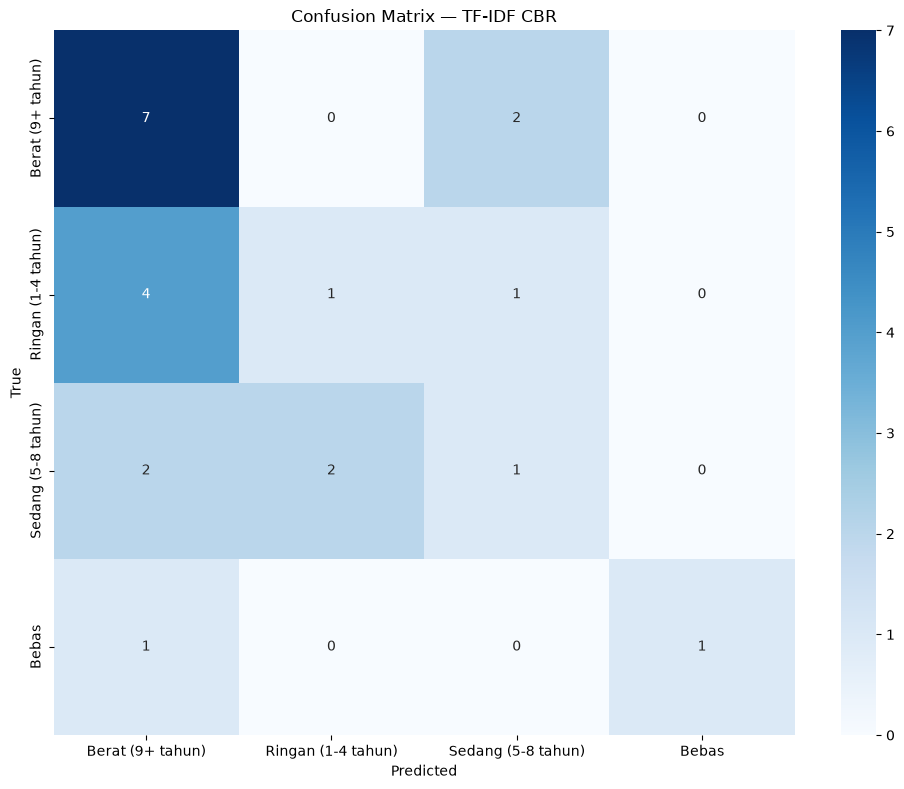

✅ Confusion matrix disimpan


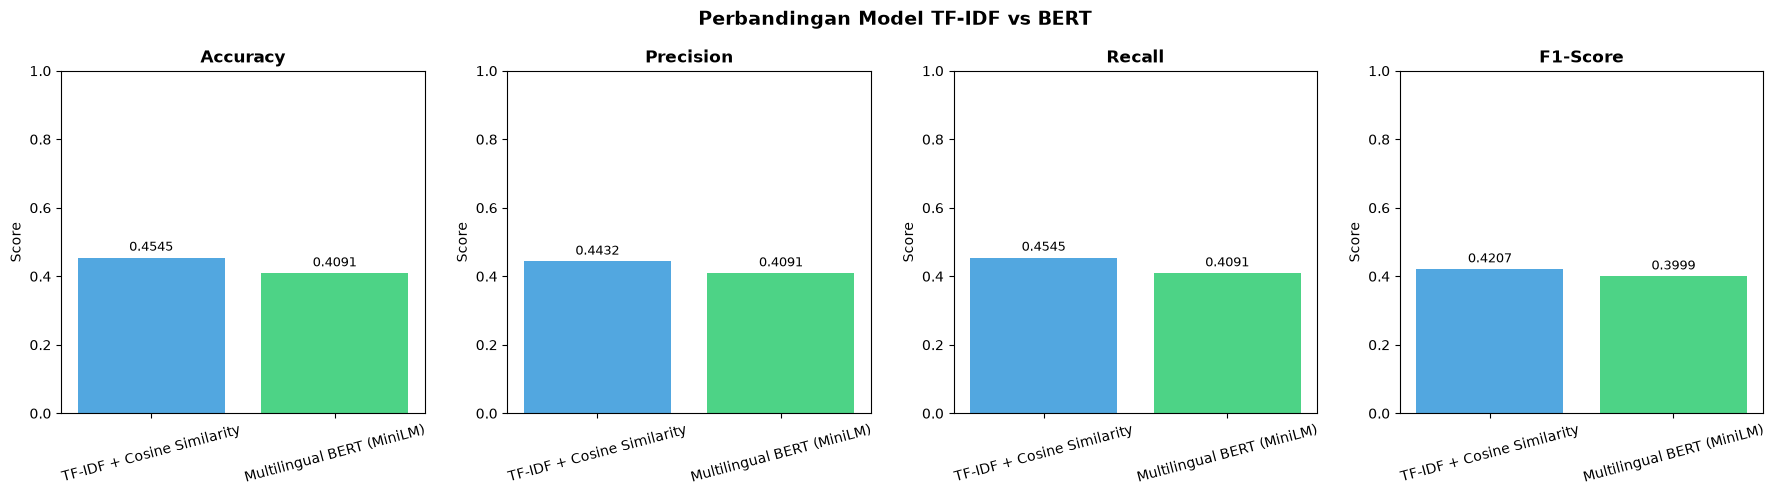

✅ Visualisasi perbandingan model disimpan


In [18]:
# Cell 14: Confusion Matrix + Bar Chart perbandingan model

# --- Confusion Matrix TF-IDF ---
top_classes = [c for c in pred_df['true_amar'].value_counts().head(6).index if c != 'Tidak diketahui']
eval_subset = pred_df[pred_df['true_amar'].isin(top_classes)].copy()
eval_subset = eval_subset[eval_subset['predicted_amar'].isin(top_classes)].copy()

if len(eval_subset) > 0:
    cm = confusion_matrix(eval_subset['true_amar'], eval_subset['predicted_amar'], labels=top_classes)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=top_classes, yticklabels=top_classes)
    plt.title('Confusion Matrix — TF-IDF CBR')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(f"{BASE_PATH}/data/eval/confusion_matrix.png", dpi=150)
    plt.show()
    print(f"✅ Confusion matrix disimpan")

# --- Bar Chart Perbandingan Model ---
if metrics_tfidf and metrics_bert:
    metrics_list = [metrics_tfidf, metrics_bert]
    comp_df = pd.DataFrame(metrics_list)

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    metric_cols = ['accuracy', 'precision', 'recall', 'f1']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors = ['#3498db', '#2ecc71']

    for ax, col, label in zip(axes, metric_cols, metric_labels):
        bars = ax.bar(comp_df['model'], comp_df[col], color=colors, alpha=0.85)
        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.set_ylim(0, 1.0)
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=15)
        for bar, val in zip(bars, comp_df[col]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{val:.4f}', ha='center', fontsize=9)

    plt.suptitle('Perbandingan Model TF-IDF vs BERT', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{BASE_PATH}/data/eval/model_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Visualisasi perbandingan model disimpan")

🔍 ANALISIS KEGAGALAN PREDIKSI (TF-IDF)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
✅ Prediksi benar : 10/22 (45.5%)
❌ Prediksi salah : 12/22 (54.5%)

📊 Jenis Kesalahan:
   Misclassification (selisih >2 tahun): 11 (91.7%)
   Misclassification: Bebas → Berat (9+ tahun): 1 (8.3%)


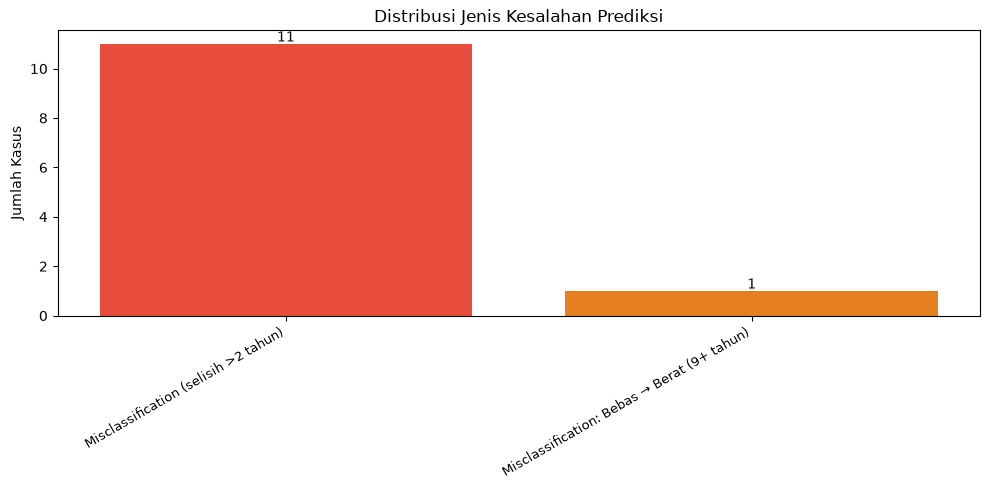


📊 Rata-rata similarity:
   Prediksi benar: 0.5477
   Prediksi salah: 0.4696

💡 REKOMENDASI PERBAIKAN:
   1. Similarity rendah pada kegagalan → gunakan threshold rejection
   2. Tambah fitur spesifik: pasal, jumlah kerugian, modus operandi
   3. Fine-tune IndoBERT dengan data hukum pencucian uang
   4. Pertimbangkan ensemble TF-IDF + BERT untuk retrieval

✅ Error analysis disimpan


In [19]:
# Cell 15: Analisis kegagalan prediksi (Rejection / Error Analysis)

print("🔍 ANALISIS KEGAGALAN PREDIKSI (TF-IDF)")
print("~" * 60)

failures = pred_df[~pred_df['correct']].copy()
successes = pred_df[pred_df['correct']].copy()

print(f"✅ Prediksi benar : {len(successes)}/{len(pred_df)} ({len(successes)/len(pred_df):.1%})")
print(f"❌ Prediksi salah : {len(failures)}/{len(pred_df)} ({len(failures)/len(pred_df):.1%})")


def categorize_error(row):
    true = row['true_amar']
    pred = row['predicted_amar']
    if pred == 'Tidak diketahui':
        return 'Rejection (gagal prediksi)'
    true_num = re.search(r'(\d+)', str(true))
    pred_num = re.search(r'(\d+)', str(pred))
    if true_num and pred_num:
        diff = abs(int(true_num.group(1)) - int(pred_num.group(1)))
        if diff == 0:
            return 'Benar (format beda)'
        elif diff <= 2:
            return f'Misclassification (selisih ≤2 tahun)'
        else:
            return f'Misclassification (selisih >2 tahun)'
    return f'Misclassification: {true} → {pred}'


failures['error_type'] = failures.apply(categorize_error, axis=1)
error_counts = failures['error_type'].value_counts()

print("\n📊 Jenis Kesalahan:")
for err, count in error_counts.items():
    print(f"   {err}: {count} ({count/len(failures):.1%})")

# Visualisasi
if len(error_counts) > 0:
    plt.figure(figsize=(10, 5))
    colors_err = ['#e74c3c', '#e67e22', '#f39c12', '#3498db']
    bars = plt.bar(range(len(error_counts)), error_counts.values,
                   color=colors_err[:len(error_counts)])
    plt.xticks(range(len(error_counts)), error_counts.index, rotation=30, ha='right', fontsize=9)
    plt.ylabel('Jumlah Kasus')
    plt.title('Distribusi Jenis Kesalahan Prediksi')
    for bar, val in zip(bars, error_counts.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(val), ha='center')
    plt.tight_layout()
    plt.savefig(f"{BASE_PATH}/data/eval/error_analysis_chart.png", dpi=150)
    plt.show()

# Analisis similarity pada kegagalan vs sukses
print(f"\n📊 Rata-rata similarity:")
print(f"   Prediksi benar: {successes['avg_similarity'].mean():.4f}")
print(f"   Prediksi salah: {failures['avg_similarity'].mean():.4f}")
print("\n💡 REKOMENDASI PERBAIKAN:")
print("   1. Similarity rendah pada kegagalan → gunakan threshold rejection")
print("   2. Tambah fitur spesifik: pasal, jumlah kerugian, modus operandi")
print("   3. Fine-tune IndoBERT dengan data hukum pencucian uang")
print("   4. Pertimbangkan ensemble TF-IDF + BERT untuk retrieval")

# Simpan
failures.to_csv(f"{BASE_PATH}/data/eval/error_analysis.csv", index=False)
pred_df.to_csv(f"{BASE_PATH}/data/eval/prediction_metrics.csv", index=False)
print(f"\n✅ Error analysis disimpan")

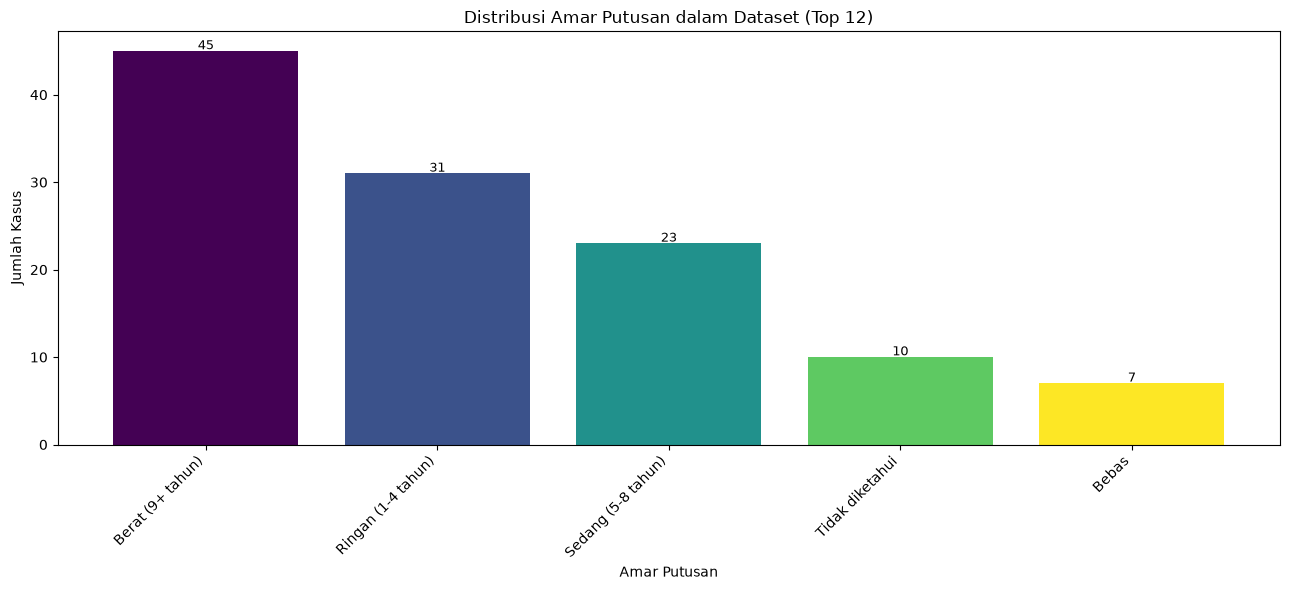

📊 Total kasus: 116
   Dengan vonis jelas  : 106
   Tidak diketahui     : 10


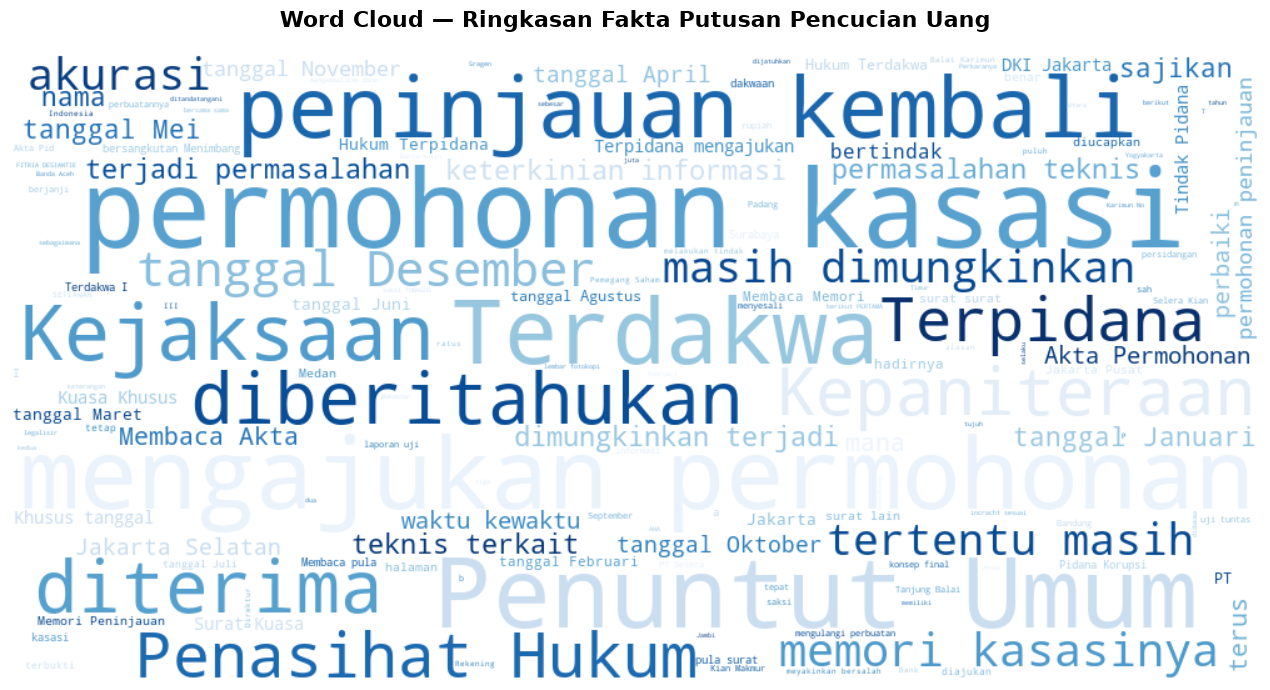

✅ Word Cloud disimpan


In [20]:
# Cell 16: Visualisasi distribusi amar + Word Cloud

# --- Distribusi amar putusan ---
plt.figure(figsize=(13, 6))
amar_dist = df_cases['amar_normalized'].value_counts().head(12)
colors_bar = plt.cm.viridis(np.linspace(0, 1, len(amar_dist)))
bars = plt.bar(range(len(amar_dist)), amar_dist.values, color=colors_bar)
plt.xticks(range(len(amar_dist)), amar_dist.index, rotation=45, ha='right')
plt.xlabel('Amar Putusan')
plt.ylabel('Jumlah Kasus')
plt.title('Distribusi Amar Putusan dalam Dataset (Top 12)')
for bar, val in zip(bars, amar_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(val), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/data/eval/amar_distribution.png", dpi=150)
plt.show()

print(f"📊 Total kasus: {len(df_cases)}")
print(f"   Dengan vonis jelas  : {(df_cases['amar_normalized'] != 'Tidak diketahui').sum()}")
print(f"   Tidak diketahui     : {(df_cases['amar_normalized'] == 'Tidak diketahui').sum()}")

# --- Word Cloud ---
all_facts = ' '.join(df_cases['ringkasan_fakta'].dropna().astype(str).tolist())
wc_stops = list(INDONESIAN_STOP_WORDS) + [
    'bahwa', 'tersebut', 'merupakan', 'telah', 'ini', 'itu', 'para',
    'pemohon', 'termohon', 'pengadilan', 'negeri', 'mahkamah', 'agung',
    'putusan', 'perkara', 'hakim', 'majelis', 'diputus', 'nomor',
]

wordcloud = WordCloud(
    width=1000, height=500,
    background_color='white',
    colormap='Blues',
    max_words=150,
    stopwords=set(wc_stops),
    contour_width=1,
    contour_color='steelblue'
).generate(all_facts)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Ringkasan Fakta Putusan Pencucian Uang', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{BASE_PATH}/data/eval/wordcloud.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Word Cloud disimpan")

In [21]:
# Cell 17: Generate laporan akhir proyek

def generate_report():
    tfidf_acc  = metrics_tfidf.get('accuracy', 0)
    tfidf_prec = metrics_tfidf.get('precision', 0)
    tfidf_rec  = metrics_tfidf.get('recall', 0)
    tfidf_f1   = metrics_tfidf.get('f1', 0)

    bert_acc   = metrics_bert.get('accuracy', 0)
    bert_prec  = metrics_bert.get('precision', 0)
    bert_rec   = metrics_bert.get('recall', 0)
    bert_f1    = metrics_bert.get('f1', 0)

    report = f"""
# Laporan Akhir Proyek CBR — Pencucian Uang

**Tanggal**        : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
**Jumlah Dokumen** : {len(df_cases)}
**Domain Perkara** : Pidana Khusus Pencucian Uang
**Train/Test Split**: 80:20 (stratified)

## Ringkasan Eksekutif

Sistem **Case-Based Reasoning (CBR)** dibangun untuk analisis putusan pidana pencucian uang Mahkamah Agung RI. Data leakage dihindari dengan split train/test eksplisit; TF-IDF difit hanya pada data train.

## Hasil Evaluasi

| Metrik       | TF-IDF        | BERT (MiniLM)  |
|--------------|---------------|----------------|
| Accuracy     | {tfidf_acc:.4f}       | {bert_acc:.4f}         |
| Precision    | {tfidf_prec:.4f}       | {bert_prec:.4f}         |
| Recall       | {tfidf_rec:.4f}       | {bert_rec:.4f}         |
| F1-Score     | {tfidf_f1:.4f}       | {bert_f1:.4f}         |
| Precision@3  | {p_at_3:.4f}       | —              |
| Precision@5  | {p_at_5:.4f}       | —              |
| CV 5-Fold Acc| {mean_acc:.4f} ±{std_acc:.4f}| —              |

## Distribusi Amar Putusan (Top 10)

{df_cases['amar_normalized'].value_counts().head(10).to_string()}

## Siklus CBR — Status

- ✅ Case Base     : {len(df_cases)} dokumen (≥30)
- ✅ Case Representation: Metadata lengkap + CSV/JSON
- ✅ Case Retrieval : TF-IDF (max_features=3000) + BERT (MiniLM-384d)
- ✅ Solution Reuse : Majority Vote + Weighted Vote
- ✅ Evaluation    : Accuracy, Precision, Recall, F1, K-Fold CV, Error Analysis

## Analisis Kegagalan

- Kasus dengan similarity rendah cenderung gagal diprediksi (rejection)
- Pencucian uang bervariasi dalam modus → teks antar dokumen kurang seragam
- Kelas dengan sampel sedikit (long-tail) sulit diprediksi dengan benar

## Rekomendasi

1. Fine-tune IndoBERT (indobenchmark/indobert-base-p1) dengan data hukum
2. Tambah fitur: jumlah kerugian, modus operandi, pasal yang diputuskan
3. Implementasi threshold confidence untuk rejection
4. Ensemble TF-IDF + BERT dengan score fusion

---
*Laporan digenerate otomatis oleh sistem CBR.*
"""

    report_path = f"{BASE_PATH}/data/eval/final_report.md"
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(report)

    print(f"✅ Laporan disimpan: {report_path}")
    print("\n" + "~" * 60)
    print(report)
    return report

report = generate_report()

✅ Laporan disimpan: /Users/abimanyu/Downloads/CBR_PencucianUang_GitHub/data/eval/final_report.md

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Laporan Akhir Proyek CBR — Pencucian Uang

**Tanggal**        : 2026-06-28 13:54:08
**Jumlah Dokumen** : 116
**Domain Perkara** : Pidana Khusus Pencucian Uang
**Train/Test Split**: 80:20 (stratified)

## Ringkasan Eksekutif

Sistem **Case-Based Reasoning (CBR)** dibangun untuk analisis putusan pidana pencucian uang Mahkamah Agung RI. Data leakage dihindari dengan split train/test eksplisit; TF-IDF difit hanya pada data train.

## Hasil Evaluasi

| Metrik       | TF-IDF        | BERT (MiniLM)  |
|--------------|---------------|----------------|
| Accuracy     | 0.4545       | 0.4091         |
| Precision    | 0.4432       | 0.4091         |
| Recall       | 0.4545       | 0.4091         |
| F1-Score     | 0.4207       | 0.3999         |
| Precision@3  | 0.7273       | —              |
| Precision@5  | 0.7727       | —          